# Netflix Data Analysis using Python

## 1. Importing Libraries

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

warnings.filterwarnings('ignore')

## 2. Loading the Dataset

In [170]:
df = pd.read_csv('netflix.csv')

## 3. Dataset Overview

In [171]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [172]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [173]:
df.shape

(8807, 12)

In [174]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [176]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## 4. Missing Value Analysis

In [177]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [178]:
round(df.isnull().sum()/df.shape[0]*100,2).sort_values(ascending = False)

,0
director,29.91
country,9.44
cast,9.37
date_added,0.11
rating,0.05
duration,0.03
show_id,0.00
type,0.00
title,0.00
release_year,0.00


## 5. Data Cleaning

In [179]:
df.dropna(subset = ['rating', 'duration'], axis = 0, inplace = True)

In [180]:
df.shape

(8800, 12)

In [181]:
df.dropna(subset = ['date_added'], axis = 0, inplace = True)

In [182]:
df.shape

(8790, 12)

In [183]:
round(df.isnull().sum()/df.shape[0]*100,2).sort_values(ascending = False)

,0
director,29.82
country,9.43
cast,9.39
show_id,0.00
title,0.00
type,0.00
date_added,0.00
release_year,0.00
rating,0.00
duration,0.00


In [184]:
df.country.value_counts().head(10)

,count
country,
United States,2809
India,972
United Kingdom,418
Japan,243
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


In [185]:
df.country.replace(np.nan, 'Unknown', inplace = True)

In [186]:
df.country.value_counts().head(10)

,count
country,
United States,2809
India,972
Unknown,829
United Kingdom,418
Japan,243
South Korea,199
Canada,181
Spain,145
France,124


In [187]:
round(df.isnull().sum()/df.shape[0]*100,2).sort_values(ascending = False)

,0
director,29.82
cast,9.39
type,0.00
show_id,0.00
title,0.00
country,0.00
date_added,0.00
release_year,0.00
rating,0.00
duration,0.00


In [188]:
df.cast.value_counts().head(10)

,count
cast,
David Attenborough,19
"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil",14
Samuel West,10
Jeff Dunham,7
"Michela Luci, Jamie Watson, Eric Peterson, Anna Claire Bartlam, Nicolas Aqui, Cory Doran, Julie Lemieux, Derek McGrath",6
Craig Sechler,6
"David Spade, London Hughes, Fortune Feimster",6
Kevin Hart,6
Iliza Shlesinger,5


In [189]:
df.cast.replace(np.nan, 'No Cast', inplace = True)

In [190]:
df.cast.value_counts().head(10)

,count
cast,
No Cast,825
David Attenborough,19
"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil",14
Samuel West,10
Jeff Dunham,7
"Michela Luci, Jamie Watson, Eric Peterson, Anna Claire Bartlam, Nicolas Aqui, Cory Doran, Julie Lemieux, Derek McGrath",6
Craig Sechler,6
"David Spade, London Hughes, Fortune Feimster",6
Kevin Hart,6


In [191]:
round(df.isnull().sum()/df.shape[0]*100,2).sort_values(ascending = False)

,0
director,29.82
show_id,0.00
type,0.00
title,0.00
cast,0.00
country,0.00
date_added,0.00
release_year,0.00
rating,0.00
duration,0.00


In [192]:
df['director'].value_counts().head(10)

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Jay Chapman,12
Youssef Chahine,12
Martin Scorsese,12


In [193]:
df.director.replace(np.nan, 'No Information', inplace = True)

In [194]:
df['director'].value_counts().head(10)

,count
director,
No Information,2621
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Jay Chapman,12
Youssef Chahine,12


In [195]:
round(df.isnull().sum()/df.shape[0]*100,2).sort_values(ascending = False)

,0
show_id,0.0
type,0.0
title,0.0
director,0.0
cast,0.0
country,0.0
date_added,0.0
release_year,0.0
rating,0.0
duration,0.0


## 6. Exploratory Data Analysis

### 6.1 Content Type Analysis

In [196]:
df.type.value_counts()

,count
type,
Movie,6126
TV Show,2664


In [197]:
type_counts = df['type'].value_counts(normalize=True)

fig = go.Figure(
    data=
     [
         go.Pie(labels=type_counts.index,
                values=type_counts.values,
                hole=0.4,
                title='Movies vs TV Shows')
         ]
    )

fig.show()

### 6.2 Rating Analysis

In [198]:
df.rating.value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


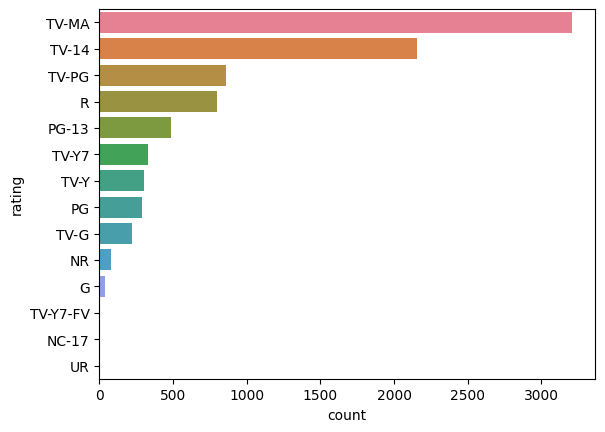

In [199]:
rating_count = df.rating.value_counts()
sns.barplot(x = rating_count, y = rating_count.index, orient = 'h', palette='husl')
plt.show()

### 6.3 Country Analysis

In [200]:
df.country.value_counts().head(10)

,count
country,
United States,2809
India,972
Unknown,829
United Kingdom,418
Japan,243
South Korea,199
Canada,181
Spain,145
France,124


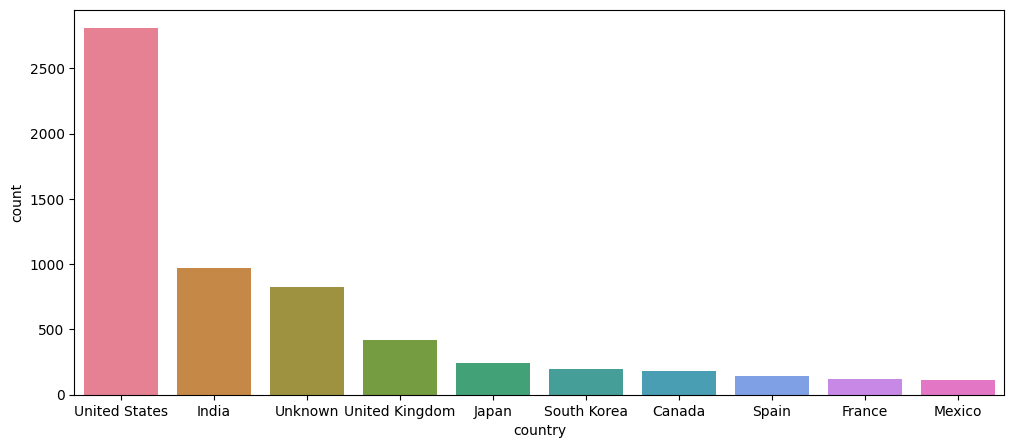

In [201]:
country_wise_data = df.country.value_counts().head(10)

plt.figure(figsize = (12,5))
sns.barplot(x = country_wise_data.index, y = country_wise_data, palette='husl')
plt.show()

### 6.4 Release Year Analysis

In [202]:
df['release_year'].value_counts().head(10)


,count
release_year,
2018,1146
2017,1030
2019,1030
2020,953
2016,901
2021,592
2015,555
2014,352
2013,286


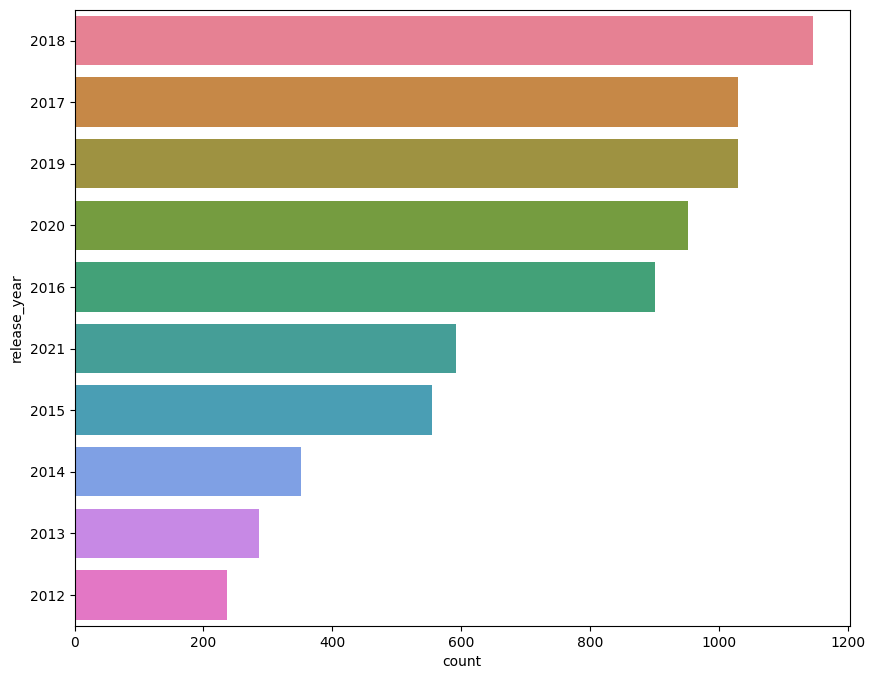

In [203]:
plt.figure(figsize = (10,8))
sns.countplot(y = 'release_year', data = df, order = df['release_year'].value_counts().index[0:10], palette = 'husl')
plt.show()

### 6.5 Genre Analysis

In [204]:
df.listed_in.value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,219
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


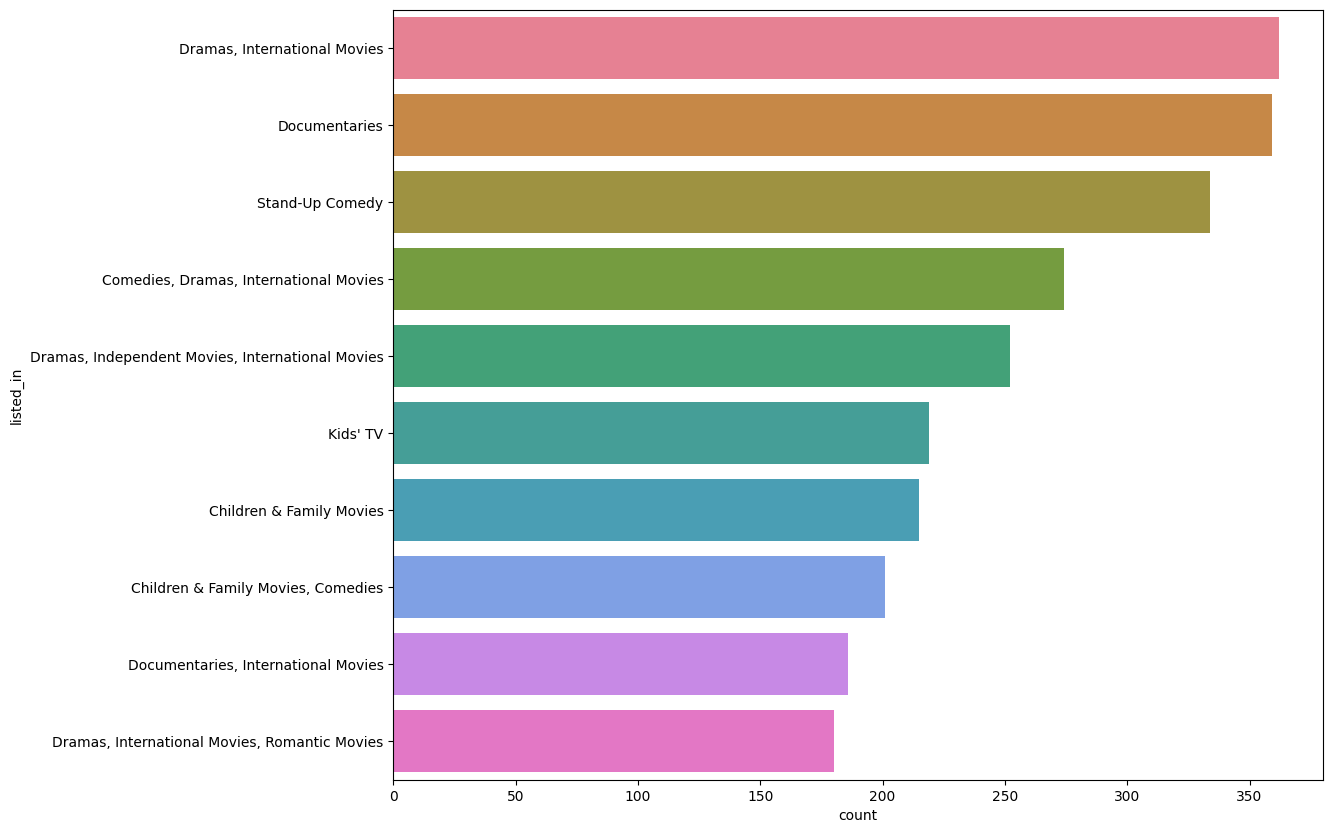

In [205]:
plt.figure(figsize = (12,10))
sns.countplot(y = 'listed_in', data = df, order = df['listed_in'].value_counts().index[0:10], palette = 'husl')
plt.show()

In [206]:
df.title

,title
0,Dick Johnson Is Dead
1,Blood & Water
2,Ganglands
3,Jailbirds New Orleans
4,Kota Factory
...,...
8802,Zodiac
8803,Zombie Dumb
8804,Zombieland
8805,Zoom


## Top 10 Actors

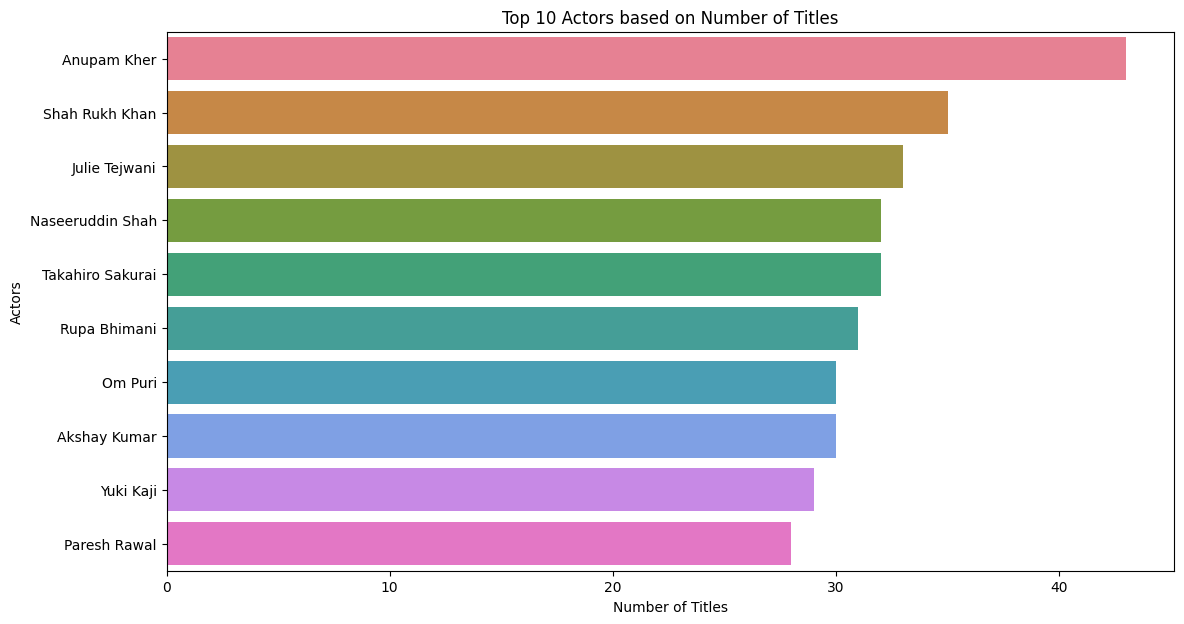

In [207]:
cast_shows = df[df['cast'] != 'No Cast']['cast'].str.split(', ').explode().reset_index(drop=True)

plt.figure(figsize=(13,7))

sns.countplot(
    y=cast_shows,
    order=cast_shows.value_counts().index[:10],
    palette = 'husl'
)

plt.title('Top 10 Actors based on Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Actors')
plt.show()

## Movie Analysis

In [208]:
movies_df = df.loc[df.type == 'Movie']
movies_df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Cast,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [209]:
movies_df.duration = movies_df.duration.replace(' min' , '', regex = True)

In [210]:
movies_df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Cast,United States,"September 25, 2021",2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,"September 24, 2021",2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127,"Dramas, International Movies",After most of her family is murdered in a terr...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",Unknown,"September 22, 2021",2021,TV-PG,91,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",No Cast,Unknown,"September 22, 2021",2020,TV-MA,67,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
18,s19,Movie,Intrusion,Adam Salky,"Freida Pinto, Logan Marshall-Green, Robert Joh...",Unknown,"September 22, 2021",2021,TV-14,94,Thrillers,After a deadly home invasion at a couple’s new...
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",Unknown,"September 21, 2021",1996,TV-PG,161,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
23,s24,Movie,Go! Go! Cory Carson: Chrissy Takes the Wheel,"Alex Woo, Stanley Moore","Maisie Benson, Paul Killam, Kerry Gudjohnsen, ...",Unknown,"September 21, 2021",2021,TV-Y,61,Children & Family Movies,From arcade games to sled days and hiccup cure...


In [211]:
movies_df.duration = movies_df.duration.astype(int)

In [212]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6126 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6126 non-null   object
 1   type          6126 non-null   object
 2   title         6126 non-null   object
 3   director      6126 non-null   object
 4   cast          6126 non-null   object
 5   country       6126 non-null   object
 6   date_added    6126 non-null   object
 7   release_year  6126 non-null   int64 
 8   rating        6126 non-null   object
 9   duration      6126 non-null   int64 
 10  listed_in     6126 non-null   object
 11  description   6126 non-null   object
dtypes: int64(2), object(10)
memory usage: 751.2+ KB


In [213]:
movies_df.describe()

,release_year,duration
count,6126.000000,6126.000000
mean,2013.120144,99.584884
std,9.681723,28.283225
min,1942.000000,3.000000
25%,2012.000000,87.000000
50%,2016.000000,98.000000
75%,2018.000000,114.000000
max,2021.000000,312.000000


In [214]:
shortest_movie = movies_df.loc[movies_df.duration == movies_df.duration.min()]
shortest_movie

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3777,s3778,Movie,Silent,"Limbert Fabian, Brandon Oldenburg",No Cast,United States,"June 4, 2019",2014,TV-Y,3,"Children & Family Movies, Sci-Fi & Fantasy","""Silent"" is an animated short film created by ..."


In [215]:
longest_movie = movies_df.loc[movies_df.duration == movies_df.duration.max()]
longest_movie

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4253,s4254,Movie,Black Mirror: Bandersnatch,No Information,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,"December 28, 2018",2018,TV-MA,312,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question..."


## Show Analysis

In [216]:
show_df = df.loc[df.type == 'TV Show']
show_df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,No Information,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,No Information,No Cast,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,No Information,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...


In [217]:
show_df.duration = show_df.duration.replace(r' Seasons?' , '' , regex = True)

In [218]:
show_df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,No Information,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,No Information,No Cast,Unknown,"September 24, 2021",2021,TV-MA,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,No Information,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,"September 24, 2021",2021,TV-MA,1,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",No Information,No Cast,Unknown,"September 24, 2021",2021,TV-MA,1,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
11,s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,"Sukollawat Kanarot, Sushar Manaying, Pavarit M...",Unknown,"September 23, 2021",2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...","Struggling to earn a living in Bangkok, a man ..."
14,s15,TV Show,Crime Stories: India Detectives,No Information,No Cast,Unknown,"September 22, 2021",2021,TV-MA,1,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
15,s16,TV Show,Dear White People,No Information,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,"September 22, 2021",2021,TV-MA,4,"TV Comedies, TV Dramas",Students of color navigate the daily slights a...


In [219]:
show_df.duration = show_df.duration.astype(int)

In [220]:
show_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2664 entries, 1 to 8803
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       2664 non-null   object
 1   type          2664 non-null   object
 2   title         2664 non-null   object
 3   director      2664 non-null   object
 4   cast          2664 non-null   object
 5   country       2664 non-null   object
 6   date_added    2664 non-null   object
 7   release_year  2664 non-null   int64 
 8   rating        2664 non-null   object
 9   duration      2664 non-null   int64 
 10  listed_in     2664 non-null   object
 11  description   2664 non-null   object
dtypes: int64(2), object(10)
memory usage: 270.6+ KB


In [221]:
show_df.describe()

,release_year,duration
count,2664.000000,2664.000000
mean,2016.627628,1.751877
std,5.735194,1.550622
min,1925.000000,1.000000
25%,2016.000000,1.000000
50%,2018.000000,1.000000
75%,2020.000000,2.000000
max,2021.000000,17.000000


## Netflix Titles Added by Month and Year

This heatmap shows the number of Netflix titles added each month across different years. It helps identify seasonal patterns and periods when Netflix added more content to its library.

In [222]:
import plotly.express as px

netflix_date = df[['date_added']].dropna()

netflix_date['year'] = netflix_date['date_added'].str.split(', ').str[-1]
netflix_date['month'] = netflix_date['date_added'].str.strip().str.split(' ').str[0]

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

heatmap_data = netflix_date.groupby(
    ['year', 'month']
).size().unstack(fill_value=0)

heatmap_data = heatmap_data.reindex(columns=month_order)

fig = px.imshow(
    heatmap_data.T,
    labels={
        'x': 'Year',
        'y': 'Month',
        'color': 'Number of Titles'
    },
    x=heatmap_data.index,      # Year → X-axis
    y=heatmap_data.columns,    # Month → Y-axis
    text_auto=True,
    aspect='auto',
    color_continuous_scale='Greens',
    title='Netflix Titles Added by Month and Year'
)

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Month',
    height=700
)

fig.show()